# Exploratory Data Analysis - Titanic Survival Prediction

 In this notebook we explore the Titanic dataset to understand its structure, distributions, relationships between features, and patterns that might help predict survival.


- How to load and inspect a dataset
- Identifying missing values
- Univariate and bivariate analysis
- Correlation analysis
- Visualizing survival patterns across different features

### 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set Plot Styles
sns.set_theme(style ="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

%matplotlib inline

### 2. Load The Dataset


In [4]:
df = pd.read_csv("Data/titanic.csv")
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head(10)

Dataset shape: 891 rows, 12 columns


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


###  Column Descriptions

| Column | Description |
|--------|-------------|
| **PassengerId** | Unique ID for each passenger |
| **Survived** | 0 = Did not survive, 1 = Survived |
| **Pclass** | Ticket class: 1 = 1st, 2 = 2nd, 3 = 3rd |
| **Name** | Passenger name |
| **Sex** | Gender |
| **Age** | Age in years |
| **SibSp** | Number of siblings/spouses aboard |
| **Parch** | Number of parents/children aboard |
| **Ticket** | Ticket number |
| **Fare** | Passenger fare |
| **Cabin** | Cabin number |
| **Embarked** | Port of embarkation: C = Cherbourg, Q = Queenstown, S = Southampton |

### 3. Dataset Overview

In [5]:
# Data types and not null counts
df.info()                                     

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
# Statistical summary of numerical columns
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
# Statistical summary of categorical columns
df.describe(include="object")


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


### 4. Missing Values Analysis

In [8]:
# Count and percentage of missing values
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": (df.isnull().sum() /len(df) * 100). round(2)
})
missing = missing[missing["Missing Count"] > 0].sort_values("Missing %", ascending=False)
print ("Columns with missing values:")
missing

Columns with missing values:


,Missing Count,Missing %
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


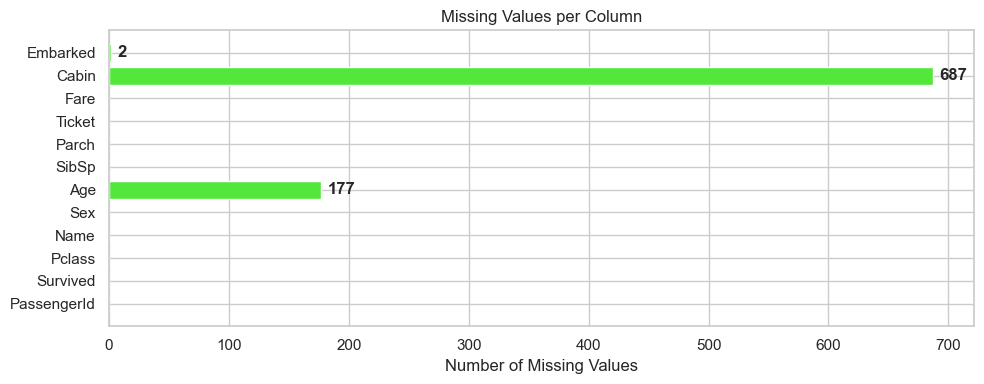

In [9]:
# Visualize missing values
fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#53e73c" if df[col].isnull().any() else "#2ecc71" for col in df.columns]
ax.barh(df.columns, df.isnull().sum(), color=colors)
ax.set_xlabel("Number of Missing Values")
ax.set_title("Missing Values per Column")
for i, v in enumerate(df.isnull().sum()):
    if v > 0:
        ax.text(v + 5, i, str(v), va="center", fontweight="bold")
plt.tight_layout()
plt.show()

*Key observations:*

- Cabin has ~77% missing values — too many to impute reliably, we'll likely drop it
- Age has ~20% missing — we can impute using group medians
- Embarked has only 2 missing values — easy to fill with the mode

### 5. Target Variable Analysis

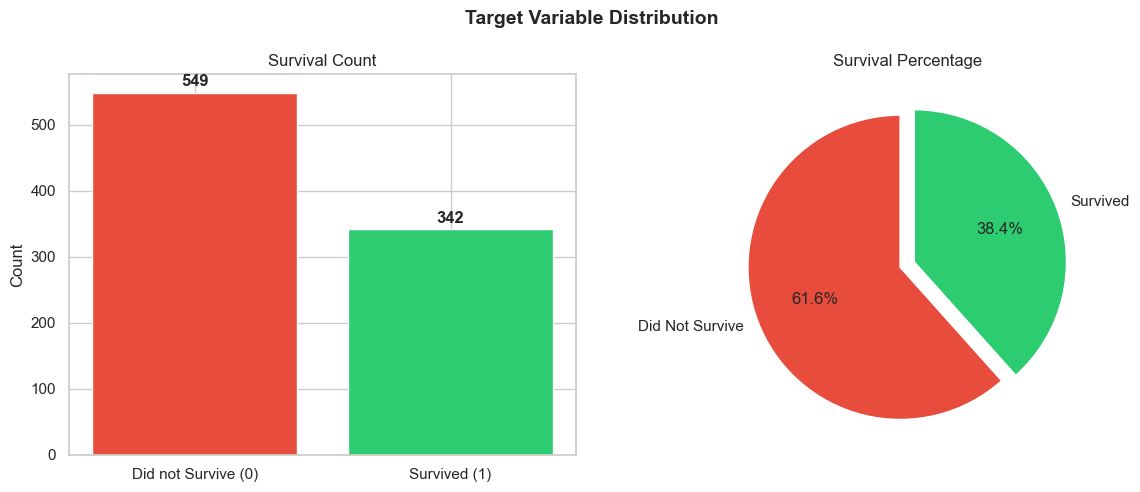


Survival rate: 38.38%
 Death rate: 61.62%


In [10]:
# Survival Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
survived_counts = df["Survived"]. value_counts()
axes[0].bar(["Did not Survive (0)", "Survived (1)"], survived_counts.values, color=["#e74c3c", "#2ecc71"])
axes[0].set_title("Survival Count")
axes[0].set_ylabel("Count")
for i, v in enumerate(survived_counts.values):
    axes[0].text(i, v + 10, str(v), ha="center", fontweight="bold")

# Pie Chart
axes[1].pie(survived_counts.values, labels=["Did Not Survive", "Survived"],
            autopct="%1.1f%%", colors=["#e74c3c", "#2ecc71"],
            startangle=90, explode=(0.05, 0.05))
axes[1].set_title("Survival Percentage")

plt.suptitle("Target Variable Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nSurvival rate: {df['Survived'].mean():.2%}")
print(f" Death rate: {1 - df['Survived'].mean():.2%}")


### Univariate Analysis - Numarical Features

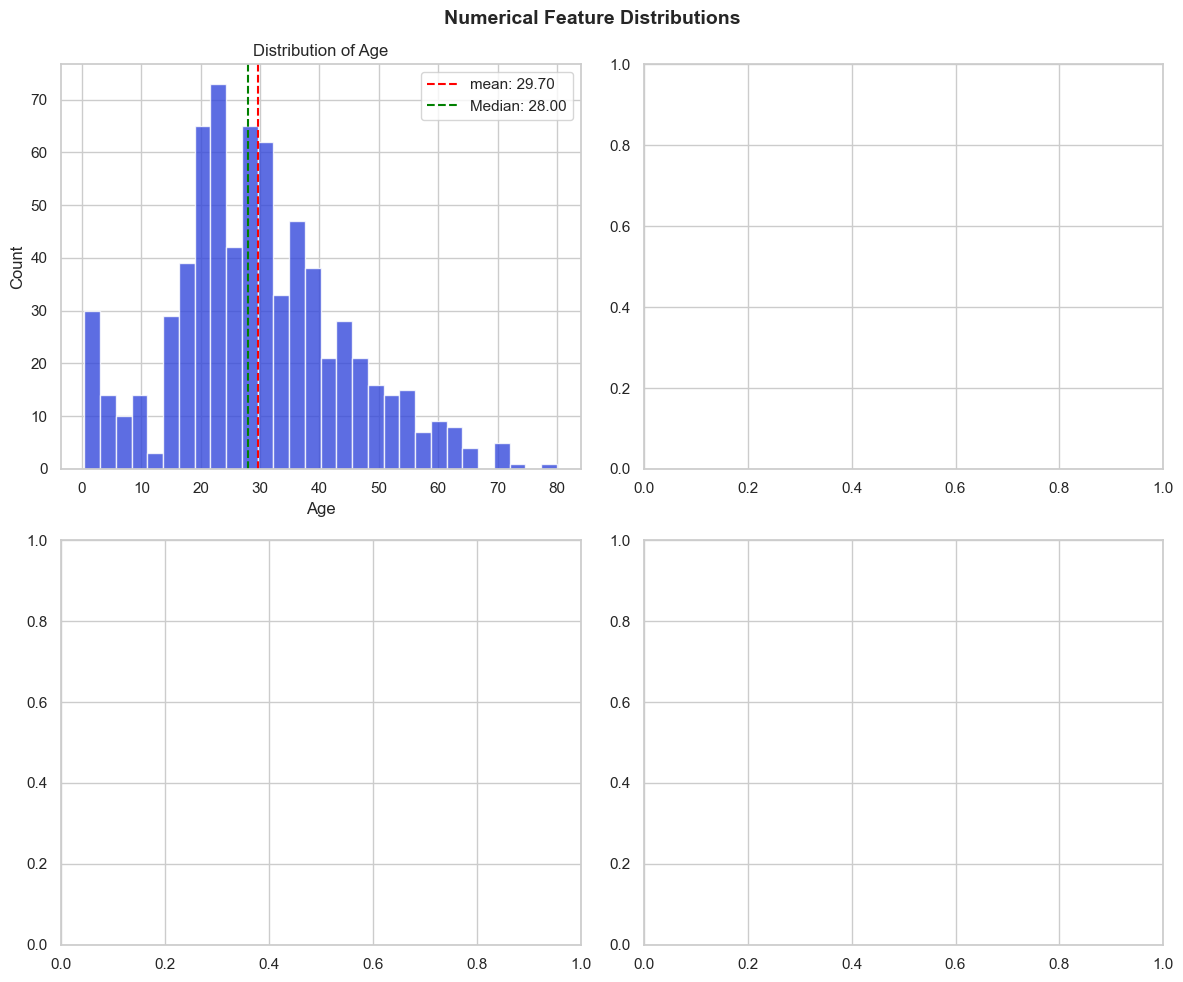

<Figure size 1000x600 with 0 Axes>

KeyError: 'Sibsp'

In [ ]:
# Distribution of numerical features
numerical_cols = ["Age", "Fare", "SibSp", "Parch"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col].dropna(), bins=30, color="#3498db", edgecolor="white", alpha=0.8)
    axes[i].axvline(df[col].mean(), color="red", linestyle="--", label=f"Mean: {df[col].mean():.2f}")
    axes[i].axvline(df[col].median(), color="green", linestyle="--", label=f"Median: {df[col].median():.2f}")
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].legend()

plt.suptitle("Numerical Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()